In [245]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [246]:

# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]


In [247]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
print(file_paths)

['/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/core_processed/core_faam_20120915_v004_r1_b732.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b732-sep-15/core_processed/core_faam_20120915_v004_r1_b732_1hz.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b733-sep-16/core_processed/core_faam_20120916_v004_r1_b733.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b733-sep-16/core_processed/core_faam_20120916_v004_r1_b733_1hz.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core_faam_20120918_v004_r1_b734.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/core_processed/core_faam_20120918_v004_r1_b734_1hz.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b735-sep-19/core_processed/core_faam_20120919_v004_r1_b735.nc', '/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b735-sep-19/core_processed/core_faam_20120919_v004_

In [248]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Print or use the collected file paths
#print("\nFiltered files:")
#print(filtered_files)


In [249]:
# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_ams)

In [250]:
# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_sp2)

In [251]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2  # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")


Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14


In [252]:
filtered_sp2[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_sp2[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

20120918


In [253]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf

In [254]:
def dataset_sp2_ams(file_path_sp2,file_path_ams):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )

    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)

    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams

In [255]:
def calculate_absortion_eff(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    filtered_time = total_mass.datetime.values  # Reference timestamps
    psap_time = aux_ds_psap["Time"].values  # Original timestamps from new dataset
    
    common_times = np.intersect1d(filtered_time, psap_time)
    
    # Create a boolean mask as an Xarray DataArray
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    mask1 = xr.DataArray(np.isin(filtered_time, common_times), dims=["time"])
    
    # Apply the mask to filter ds_psap
    ds_psap_matched = aux_ds_psap.where(mask, drop=True)
    total_mass_matched = total_mass.where(mask1, drop=True)
    
    
    return ds_psap_matched,total_mass_matched

In [256]:
ds_sp2,ds_ams = dataset_sp2_ams(filtered_sp2[0],filtered_ams[0])

In [257]:
ds_psap = xr.open_dataset(filtered_nc[0])
#valid_PSAP_mask = ds_psap["PSAP_LIN_FLAG"] == 0
#filtered_ds_psap = ds_psap.where(valid_PSAP_mask, drop=False)
ds_test,tm_test=calculate_absortion_eff(ds_sp2,ds_ams,ds_psap)

In [258]:
valid_PSAP_mask = ds_test["PSAP_LIN_FLAG"] == 0
filtered_ds_psap = ds_test.where(valid_PSAP_mask, drop=False)
print(np.shape(tm_test.values))
print(np.shape(ds_test['PSAP_LIN']))

(773,)
(773, 1)


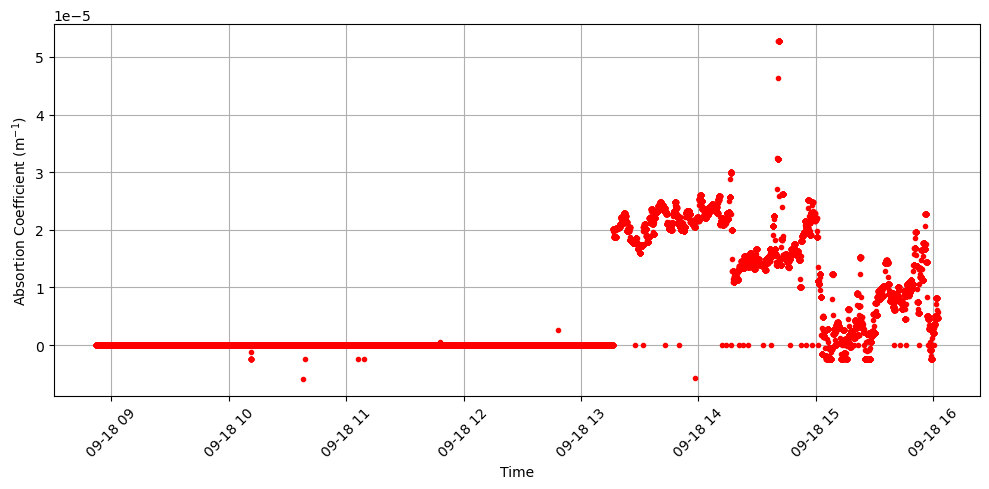

25820

In [259]:
# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(ds_psap['Time'], ds_psap['PSAP_LIN'], color="r", marker='.',linewidth=0)
#plt.plot(ds_test['Time'], ds_test['PSAP_LIN'], color="b", marker='o', linestyle='', markersize=4)
#plt.xlim(ds_test['Time'][200],ds_test['Time'][3500])
plt.xlabel('Time')
plt.ylabel(r'Absortion Coefficient ($\mathrm{m^{-1}}$)')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()
len(ds_psap['PSAP_LIN'])

In [260]:
valid_PSAP_mask = ds_test["PSAP_LIN_FLAG"] == 0
filtered_ds_psap = ds_test.where(valid_PSAP_mask, drop=False)
filtered_ds_psap_aux = ds_test.where(valid_PSAP_mask, drop=True)
# Create a boolean mask as an Xarray DataArray
# Ensure both arrays are 1D and aligned
psap_values = filtered_ds_psap["PSAP_LIN"].values.squeeze()
tm_values = tm_test.squeeze()

# Perform element-wise division, ignoring NaNs
result = np.divide(psap_values, tm_values*1e-6)

# Drop NaN values from the result if needed
Mass_absortion_eff = result.where(~np.isnan(result), drop=True)

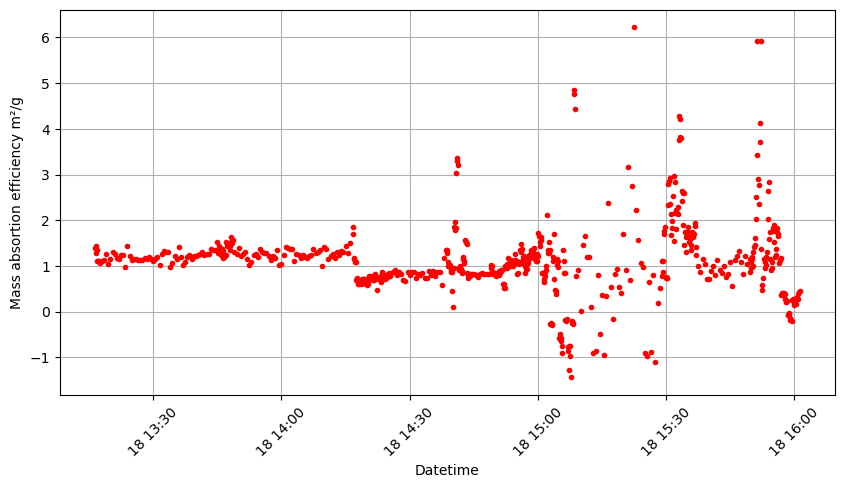

In [261]:
# Plot SO4 vs. datetime
plt.figure(figsize=(10, 5))
plt.plot(filtered_ds_psap_aux['Time'].squeeze(), Mass_absortion_eff, color="r", marker='.',linewidth=0)
#plt.xlim(filtered_ds_psap['Time'][550],filtered_ds_psap['Time'][3000])

# Formatting
plt.xlabel("Datetime")
plt.ylabel("Mass absortion efficiency m²/g")
#plt.title("Mass absortion efficiency Over Time")
plt.xticks(rotation=45)
plt.grid()

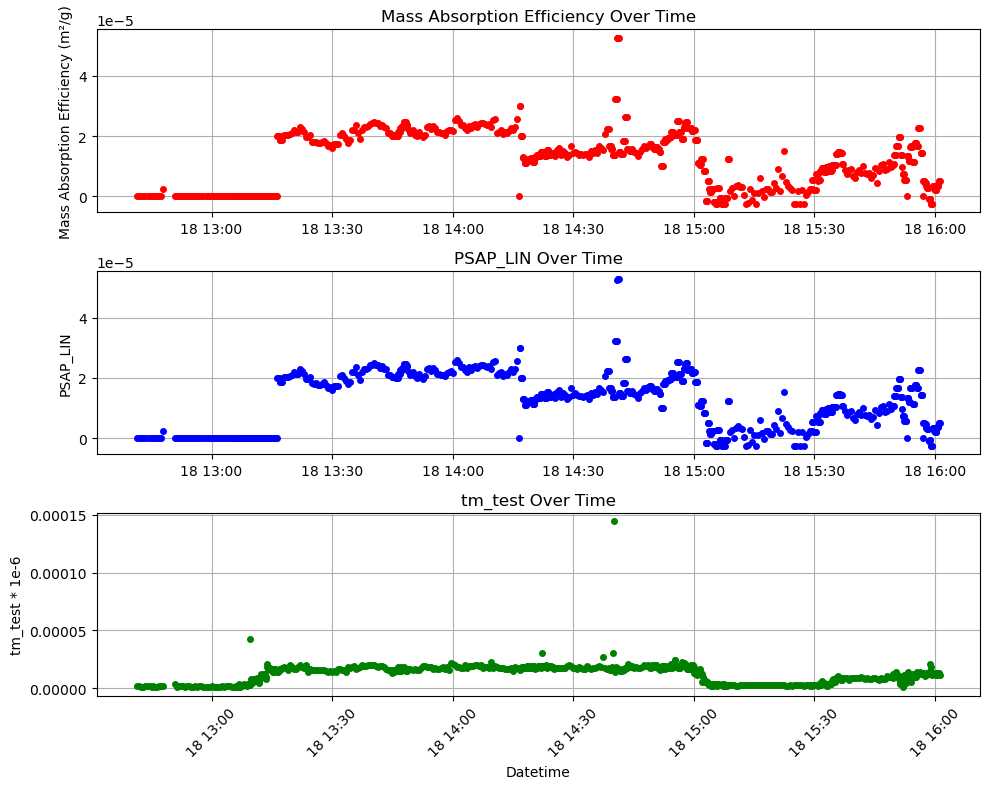

In [262]:
# Create subplots (3 rows, 1 column) with a shared x-axis
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)

# Plot Mass Absorption Efficiency (Red Dots)
axes[0].plot(ds_test['Time'].squeeze(),ds_test['PSAP_LIN'], color="r", marker='o', linestyle='', markersize=4)
axes[0].set_ylabel("Mass Absorption Efficiency (m²/g)")
axes[0].set_title("Mass Absorption Efficiency Over Time")
axes[0].grid()

# Plot PSAP_LIN (Blue Dots)
axes[1].plot(ds_test['Time'], ds_test['PSAP_LIN'], color="b", marker='o', linestyle='', markersize=4)
axes[1].set_ylabel("PSAP_LIN")
axes[1].set_title("PSAP_LIN Over Time")
axes[1].grid()

# Plot tm_test * 1e-6 (Green Dots)
axes[2].plot(tm_test['datetime'], tm_test.values * 1e-6, color="g", marker='o', linestyle='', markersize=4)
axes[2].set_ylabel("tm_test * 1e-6")
axes[2].set_title("tm_test Over Time")
axes[2].set_xlabel("Datetime")  # Only the last subplot has an x-axis label
axes[2].grid()

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [263]:
# Compute the mean, handling cases where the list might be empty
mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff) 
std_mass_absorption_eff_g = np.nanstd(Mass_absortion_eff) 
mean_std = std_mass_absorption_eff_g/np.sqrt(len(Mass_absortion_eff))

# Print results
print(f"Mean Mass Absortion Efficiency (g): {mean_mass_absorption_eff_g:.3f} m²/g")
print(f"Standard Deviation: {std_mass_absorption_eff_g:.3f} m²/g")
print(f"Mean Standard Deviation: {mean_std:.3f} m²/g")

Mean Mass Absortion Efficiency (g): 1.115 m²/g
Standard Deviation: 0.833 m²/g
Mean Standard Deviation: 0.033 m²/g


In [264]:
# List to store results
results = []

# Iterate over all matching flights
for sp2_file, ams_file, nc_file in zip(filtered_sp2, filtered_ams, filtered_nc):

    print(sp2_file)
    ds_sp2,ds_ams = dataset_sp2_ams(sp2_file,ams_file)
    
    ds_psap = xr.open_dataset(nc_file)

    ds_test,tm_test=calculate_absortion_eff(ds_sp2,ds_ams,ds_psap)

    valid_PSAP_mask = ds_test["PSAP_LIN_FLAG"] == 0
    filtered_ds_psap = ds_test.where(valid_PSAP_mask, drop=False)
    #filtered_ds_psap_aux = ds_test.where(valid_PSAP_mask, drop=True)
    # Create a boolean mask as an Xarray DataArray
    # Ensure both arrays are 1D and aligned
    psap_values = filtered_ds_psap["PSAP_LIN"].values.squeeze()
    tm_values = tm_test.squeeze()
    
    # Perform element-wise division, ignoring NaNs
    result = np.divide(psap_values, tm_values*1e-6)
    
    # Drop NaN values from the result if needed
    Mass_absortion_eff = result.where(~np.isnan(result), drop=True)

    # Compute the mean, handling cases where the list might be empty
    mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff) 
    std_mass_absorption_eff_g = np.nanstd(Mass_absortion_eff) 
    mean_std = std_mass_absorption_eff_g/np.sqrt(len(Mass_absortion_eff))
    
    # Print results
    #print(f"Mean Mass Absortion Efficiency (g): {mean_mass_absorption_eff_g:.3f} m²/g")
    #print(f"Standard Deviation: {std_mass_absorption_eff_g:.3f} m²/g")
    #print(f"Mean Standard Deviation: {mean_std:.3f} m²/g")

    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"
    

    # Store results in a list
    results.append({
        "flight": flight_number,
        "mean_mass_absorption_eff_g": mean_mass_absorption_eff_g,
        "std_mass_absorption_eff_g": std_mass_absorption_eff_g,
        "mean_std": mean_std,
        "N": len(Mass_absortion_eff)
    })

/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b734-sep-18/non-core/man-sp2_faam_20120918_r0_b734.na
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b737-sep-20/non-core/man-sp2_faam_20120920_r0_b737.na
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b739-sep-23/non-core/man-sp2_faam_20120923_r0_b739.na
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b740-sep-25/non-core/man-sp2_faam_20120925_r0_b740.na
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b741-sep-26/non-core/man-sp2_faam_20120926_r0_b741.na
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b742-sep-27/non-core/man-sp2_faam_20120927_r0_b742.na
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b743-sep-27/non-core/man-sp2_faam_20120927_r0_b743.na
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b744-sep-28/non-core/man-sp2_faam_20120928_r0_b744.na
/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012/b745-sep-28/non-core/man-sp2

In [265]:
# Print results
for res in results:
    print(f"Flight {res['flight']}: {res['mean_mass_absorption_eff_g']:.3f} m²/g")

Flight b734: 1.115 m²/g
Flight b737: 1.025 m²/g
Flight b739: 0.819 m²/g
Flight b740: 1.095 m²/g
Flight b741: 3.058 m²/g
Flight b742: 2.079 m²/g
Flight b743: 1.833 m²/g
Flight b744: 2.137 m²/g
Flight b745: 1.525 m²/g
Flight b746: 2.269 m²/g
Flight b747: 1.714 m²/g
Flight b748: 1.930 m²/g
Flight b749: 1.801 m²/g
Flight b750: 1.490 m²/g


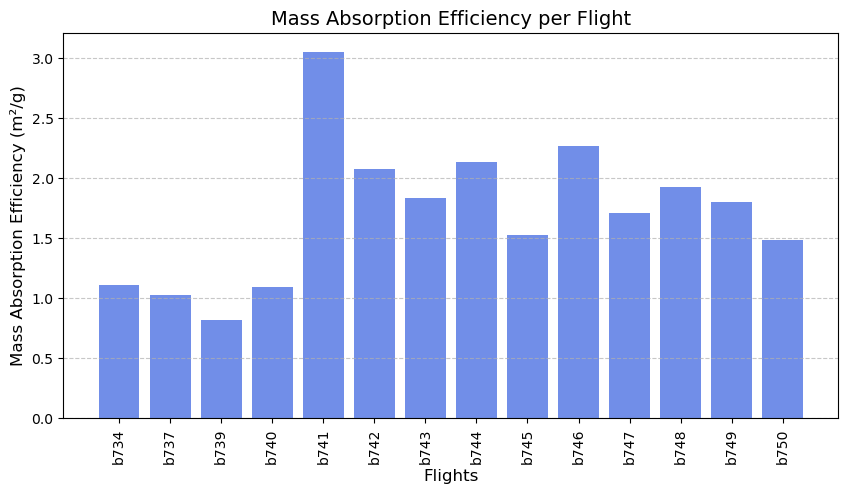

In [266]:
# Extract flight numbers and mass absorption efficiency values
flight_numbers = [res["flight"] for res in results]
mass_absorption_eff_g_values = [res["mean_mass_absorption_eff_g"] for res in results]

# Create the plot
plt.figure(figsize=(10, 5))
plt.bar(flight_numbers, mass_absorption_eff_g_values, color='royalblue', alpha=0.75)

# Labels and title
plt.xlabel("Flights", fontsize=12)
plt.ylabel("Mass Absorption Efficiency (m²/g)", fontsize=12)
plt.title("Mass Absorption Efficiency per Flight", fontsize=14)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

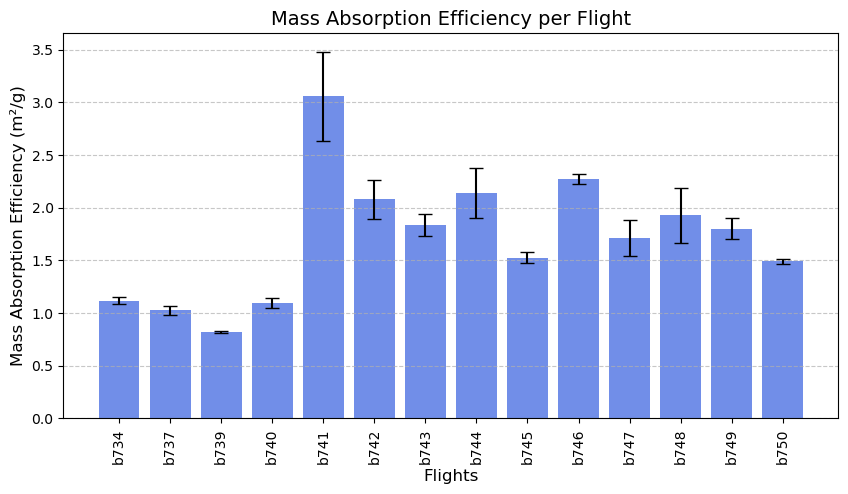

In [267]:
# Extract flight numbers, mean values, and standard deviation (error)
flight_numbers = [res["flight"] for res in results]
mean_mass_absorption_eff_g_values = [res["mean_mass_absorption_eff_g"] for res in results]
mean_std_values = [res["mean_std"] for res in results]  # Error bars

# Create the plot
plt.figure(figsize=(10, 5))
plt.bar(
    flight_numbers,
    mean_mass_absorption_eff_g_values,
    yerr=mean_std_values,  # Add error bars
    capsize=5,  # Add caps on error bars
    color='royalblue',
    alpha=0.75
)

# Labels and title
plt.xlabel("Flights", fontsize=12)
plt.ylabel("Mass Absorption Efficiency (m²/g)", fontsize=12)
plt.title("Mass Absorption Efficiency per Flight", fontsize=14)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


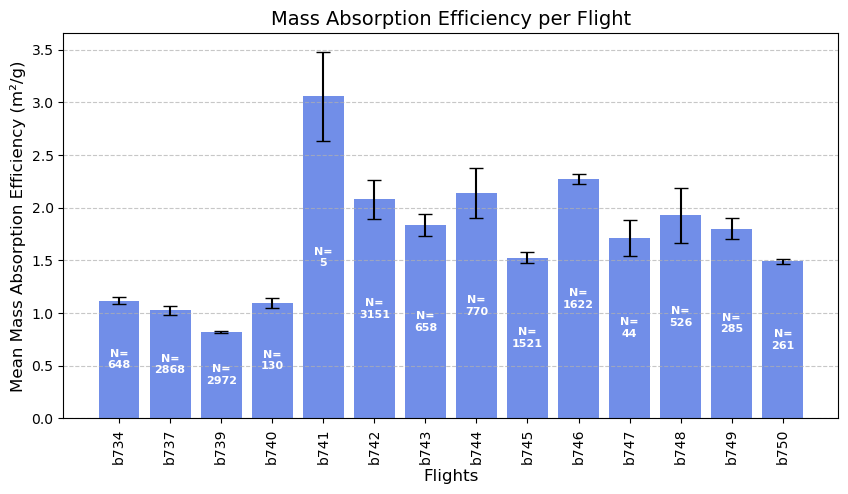

In [268]:
# Extract flight numbers, mean values, standard deviation, and N
flight_numbers = [res["flight"] for res in results]
mean_mass_absorption_eff_g_values = [res["mean_mass_absorption_eff_g"] for res in results]
mean_std_values = [res["mean_std"] for res in results]  # Error bars
n_values = [res["N"] for res in results]  # Number of measurements

# Create the plot
plt.figure(figsize=(10, 5))
bars = plt.bar(
    flight_numbers,
    mean_mass_absorption_eff_g_values,
    yerr=mean_std_values,  # Add error bars
    capsize=5,  # Add caps on error bars
    color='royalblue',
    alpha=0.75
)

# Labels and title
plt.xlabel("Flights", fontsize=12)
plt.ylabel("Mean Mass Absorption Efficiency (m²/g)", fontsize=12)
plt.title("Mass Absorption Efficiency per Flight", fontsize=14)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text inside the bars to show N
for bar, n in zip(bars, n_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height/2, f"N=\n{n}", ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Show the plot
plt.show()